In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
sandwich = pd.read_csv(r'a-fanning-doughnut-v3-a0460e5\Analysis-Final\myData\12_20250515_globalDoughnutData_2000-2022.csv')

In [3]:
sandwich

,domain,dimension,type,group,grpCode,indicator,indCode,unit,date,value,boundary,shortfallOvershoot_pct
0,ecological,climate change,global doughnut,World,WLD,co2_ppm,CC1,ppm CO2,2000,368.96,350.0,27.1
1,ecological,climate change,global doughnut,World,WLD,co2_ppm,CC1,ppm CO2,2001,370.57,350.0,29.4
2,ecological,climate change,global doughnut,World,WLD,co2_ppm,CC1,ppm CO2,2002,372.58,350.0,32.3
3,ecological,climate change,global doughnut,World,WLD,co2_ppm,CC1,ppm CO2,2003,375.14,350.0,35.9
4,ecological,climate change,global doughnut,World,WLD,co2_ppm,CC1,ppm CO2,2004,376.95,350.0,38.5
...,...,...,...,...,...,...,...,...,...,...,...,...
800,social,peace and justice,global doughnut,World,WLD,homicideOver5,PJ2,percent,2018,16.81,0.0,16.8
801,social,peace and justice,global doughnut,World,WLD,homicideOver5,PJ2,percent,2019,15.36,0.0,15.4
802,social,peace and justice,global doughnut,World,WLD,homicideOver5,PJ2,percent,2020,20.53,0.0,20.5
803,social,peace and justice,global doughnut,World,WLD,homicideOver5,PJ2,percent,2021,20.81,0.0,20.8


In [4]:
sandwich = sandwich[sandwich['group'] == 'World']
sandwich = sandwich[sandwich['type'] == 'global doughnut']

In [5]:
# no need for value of boundary column ssince the overshoot/shortfall are already 
# included in the shortfallOvershoot_pct column.
sandwich = sandwich[['domain', 'dimension', 'indicator', 'date', 'shortfallOvershoot_pct' ]]

In [6]:
# have only start and end date lines
sandwich.sort_values(['indicator', 'date'], inplace=True)
# remove racialInequality indicator because all values of column value are equal to nan and
# therefore is unusable
sandwich = sandwich[sandwich['indicator'] != 'racialInequality']
#filter dataset to include only desired dates
for indicator in sandwich['indicator'].unique() :
    earliest_value, early_date = sandwich.loc[
        (sandwich['indicator'] == indicator) & sandwich['shortfallOvershoot_pct'].notna()
    ].sort_values('date')[['shortfallOvershoot_pct', 'date']].iloc[0]
    # all indicators have values for 2022 (last date for dataset)
    sandwich = sandwich[~((sandwich['indicator'] == indicator) & (sandwich['date'] != early_date) & (sandwich['date'] != 2022))]

In [7]:
# use map to have the same indicator names with those in assignment sheet
indicator_map = {
    "govRegimes": "Autocratic regimes",
    "under5death": "Child mortality",
    "foodInsecurity": "Food insecurity",
    "genderInequalityIndex": "Gender inequality",
    "homicideOver5": "Homicides",
    "adultLiteracy": "Illiteracy",
    "urbanSlums": "Inadequate housing",
    "palma": "Income inequality",
    "secondarySchool": "Incomplete secondary school",
    "energyIndoor": "Lack of clean fuels indoors",
    "energyAccess": "Lack of electricity",
    "UHCindex": "Lack of health services",
    "internet": "Lack of internet",
    "publicTrans": "Lack of public transport",
    "socialSupport": "Lack of social support",
    "controlCorruption": "Perceptions of corruption",
    "societalPoverty": "Societal poverty",
    "undernourishment": "Undernourishment",
    "drinkingH2O": "Unsafe drinking water",
    "sanitation": "Unsafe sanitation",
    "youthNEET": "Youth unemployment",
    
    "interhemAOD": "Aerosol optical depth",
    "omega_a": "Aragonite saturation",
    "blueDev": "Blue-water flows",
    "co2_ppm": "CO2 concentration",
    "forestAreaMKM2": "Forest area",
    "chemicalsMt_Hzd": "Hazardous chemicals production",
    "hanppGtC": "Human appropriation of energy production",
    "nitrogenMt": "Nitrogen pollution",
    "phosphorusMt": "Phosphorus pollution",
    "erf_wm2": "Radiative forcing",
    "soilDev": "Soil moisture",
    "extinction1900": "Species extinctions",
    "totalOzone": "Stratospheric ozone concentration"
}

sandwich['indicator'] = sandwich['indicator'].map(indicator_map)

In [8]:
#change date values for easier visualization
sandwich['date'] = sandwich['date'].astype(str)
sandwich.loc[sandwich['date'] == '2022', 'date'] = 'last'
sandwich.loc[sandwich['date'] != 'last', 'date'] = 'first'

In [9]:
eco_sand = (
    sandwich[sandwich['domain'] == 'ecological'].pivot_table(index='indicator', columns='date', values='shortfallOvershoot_pct')
    .reset_index()
)
eco_sand.columns.name = None

social_sand = (
    sandwich[sandwich['domain'] == 'social'].pivot_table(index='indicator', columns='date', values='shortfallOvershoot_pct')
    .reset_index()
)
social_sand.columns.name = None

In [10]:
eco_sand

,indicator,first,last
0,Aerosol optical depth,-28.6,-28.6
1,Aragonite saturation,-34.2,-5.2
2,Blue-water flows,74.8,82.3
3,CO2 concentration,27.1,95.8
4,Forest area,54.4,60.9
5,Hazardous chemicals production,1413.9,3214.5
6,Human appropriation of energy production,161.2,204.5
7,Nitrogen pollution,113.3,213.4
8,Phosphorus pollution,118.5,273.7
9,Radiative forcing,76.8,191.5


Unlike the ecological indicators were all values are greater in the end than in the beggining, the social
indicators have mixed results.  
As such we need to add this to our visualization logic and create first the column of the greater value for each column. We will show the smaller value always with the same color and the greater value with different colors depending on if it is the first or last value. 

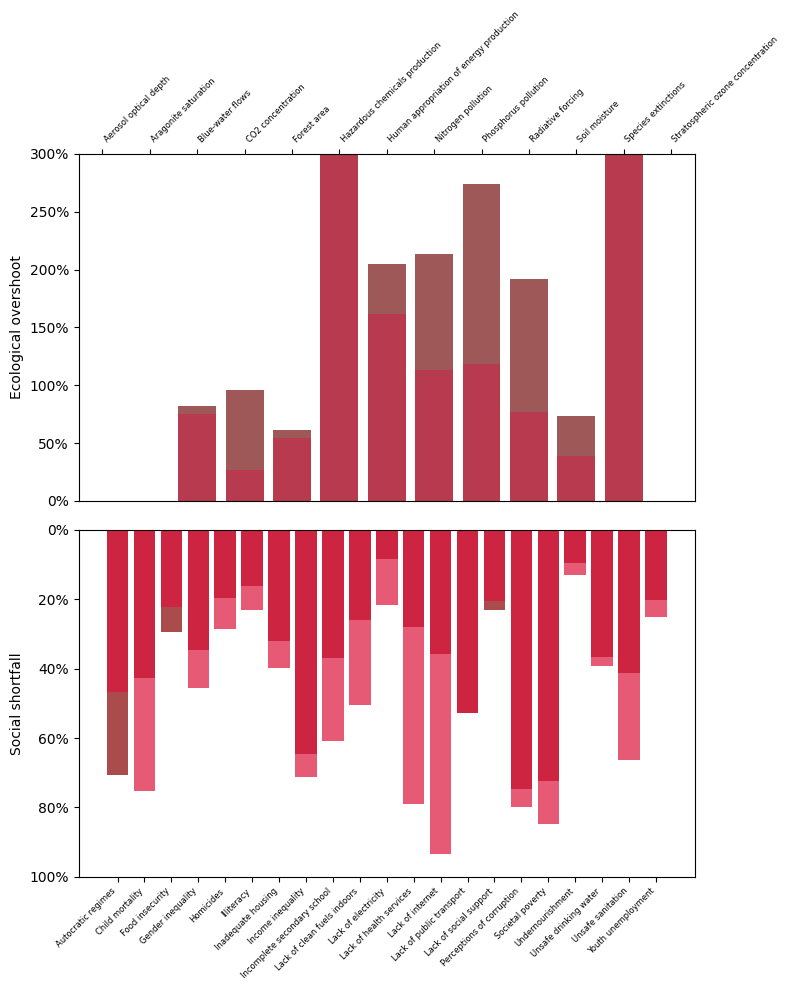

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# ecological overshoot plot
sns.barplot(x='indicator', y='last', data=eco_sand, color='#ab4c4c', ax=ax1)
sns.barplot(x='indicator', y='first', data=eco_sand, color='#cd2541', ax=ax1)
ax1.set_xlabel('')
ax1.set_ylabel('Ecological overshoot')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', labelrotation=45, labelsize=6)
plt.setp(ax1.get_xticklabels(), ha='left')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, 300)

# social shortfall plot
for _, row in social_sand.iterrows():
    if row['first'] > row['last']:
        ax2.bar(row['indicator'], row['first'], color='#e65a76')
        ax2.bar(row['indicator'], row['last'], color='#cd2541')
    else:
        ax2.bar(row['indicator'], row['last'], color='#ab4c4c')
        ax2.bar(row['indicator'], row['first'], color='#cd2541')

ax2.set_xlabel('')
ax2.set_ylabel('Social shortfall')
ax2.tick_params(axis='x', labelrotation=45, labelsize=6)
plt.setp(ax2.get_xticklabels(), ha='right')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(100, 0)

plt.tight_layout()
plt.show()

## DOUGHNUT PLOT

We can use the same dataframes for the doughnut plot but we only need the lines where date equals 'last'.

The type of graph we want to create is some sort of sunburst chart. Additionally, we want to create an interactive visualization. With that in mind we want to have a final Dash product, which is supported by the plotly librairy.
Despite the fact that plotly has a sunburst chart librairy (https://plotly.com/python/sunburst-charts/) what we want can not be supported by t and as such we will simulate the effect of a sunburst chart using the polar chart librairy (https://plotly.com/python/polar-chart/)

In [17]:
import plotly.graph_objects as go
import numpy as np

In [18]:
sandwich.reset_index(drop=True, inplace=True)
sandwich.head()

,domain,dimension,indicator,date,shortfallOvershoot_pct
0,social,health,Lack of health services,first,79.1
1,social,health,Lack of health services,last,28.1
2,social,education,Illiteracy,first,23.1
3,social,education,Illiteracy,last,16.2
4,ecological,freshwater disruption,Blue-water flows,first,74.8


In [27]:
donut_eco = sandwich[(sandwich['domain'] == 'ecological') & (sandwich['date'] == 'last')].copy()

In the literature, like the Stockholm Resilience Centre and the Doughnut Economics Action Lab. (e.g. https://www.stockholmresilience.org/research/planetary-boundaries.html), the indicators (ecological and social) are ordered thematically to improve the clarity and readability of the visualization by placing related dimensions next to each other. To ensure consistency with relevant papers, documents...etc we will follow the literature sorting of the indicators

In [31]:
eco_order = [
    'CO2 concentration',
    'Radiative forcing',
    'Aragonite saturation',
    'Hazardous chemicals production',
    'Phosphorus pollution',
    'Nitrogen pollution',
    'Aerosol optical depth',
    'Blue-water flows',
    'Soil moisture',
    'Forest area',
    'Species extinctions',
    'Human appropriation of energy production',
    'Stratospheric ozone concentration',
]

donut_eco['indicator'] = pd.Categorical(donut_eco['indicator'], categories=eco_order, ordered=True)
donut_eco = donut_eco.sort_values('indicator').reset_index(drop=True)

In [51]:
donut_eco.columns

Index(['domain', 'dimension', 'indicator', 'date', 'shortfallOvershoot_pct'], dtype='object')

For go.Barpolar, wedge area is equal to 0.5 × r² × width_in_radians.
As such we have to create create the apropriate width column. Additionaly, we have to create our own custom color mapping formula to show the values of wedges.

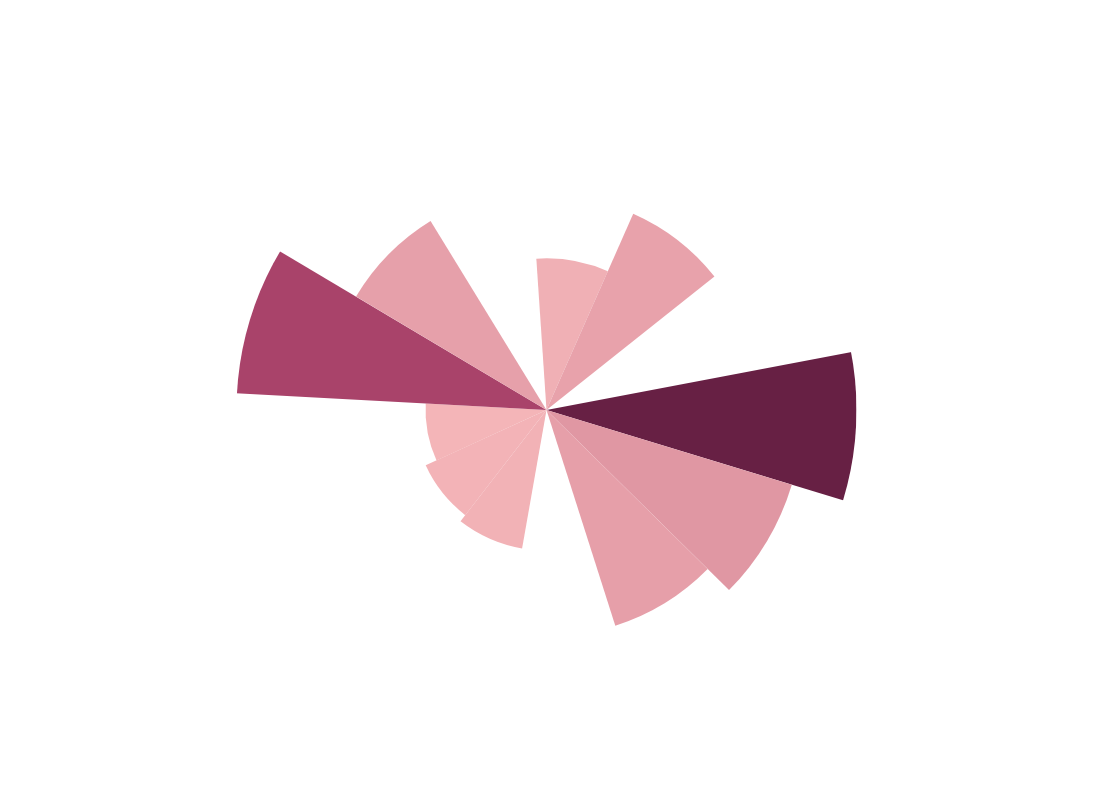

In [58]:
fig = go.Figure(go.Barpolar(
    r=[np.sqrt(max(v, 0)) for v in donut_eco['shortfallOvershoot_pct']],
    width=360/13,
    marker=dict(
        color=donut_eco['shortfallOvershoot_pct'],
        # Intermediate stop at 0.28 to prevent haz. chem. prod.
        # from compressing all other indics into the low-end color.
        # 0.28 was chosen because overshoot of (haz chem prod) * 0.28
        # approximatelly species ext over.(2nd greater over. value)
        colorscale=[[0, '#ffc6c4'], [0.28, '#aa446b'], [1, '#672044']],
        cmin=donut_eco['shortfallOvershoot_pct'].min(),
        cmax=donut_eco['shortfallOvershoot_pct'].max(),
        showscale=False
    ),
    text=donut_eco['indicator'],
    customdata=donut_eco['shortfallOvershoot_pct'],
    hovertemplate='<b>%{text}</b><br>Overshoot: %{customdata:.1f}%<extra></extra>'
))


fig.update_layout(
    template=None,
    width=800,
    height=800,
    polar=dict(
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(
            range = [0,20],
            showgrid=False,
            showline=False,
            showticklabels=False,
            ticks=''
        ),
        angularaxis=dict(
            rotation=80,
            direction='clockwise',
            showgrid=False,
            showline=False,
            showticklabels=False,
            ticks=''
        )
    )
)

fig.show()

In [ ]:
!git add Sand